# Exporting Waveforms as NPZ Files

**Scott Prahl**

**Apr 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import os
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', tempfile.mkdtemp())

import matplotlib.pyplot as plt
import numpy as np
from RigolWFM import Wfm

repo = 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/'

def sample_url(relative_path: str) -> str:
    return repo + relative_path

## Introduction

`RigolWFM` can export any parsed analog or digital waveform to a NumPy `.npz` archive.
The archive contains a uniform `time` axis, `start`, `increment`, and one array per exported channel.

This notebook shows the export path for a two-channel analog waveform.

## NPZ Export From an Analog Capture

We will start with a two-channel DS1102E waveform and export it to a NumPy archive.

In [2]:
analog = Wfm.from_url(sample_url('wfm/DS1102E-D.wfm'))
print(analog.describe())

    General:
        File Model   = DS1000E
        User Model   = auto
        Parser Model = wfm1000e
        Firmware     = unknown
        Filename     = DS1102E-D.wfm
        Channels     = [1, 2]

    Trigger:
        Mode     = edge
        Source   = CH1
        Level    = 1.60  V
        Sweep    = AUTO
        Coupling = DC
        Derived Level     = -1.20  V

     Channel 1:
         Coupling =  unknown
            Scale =     2.00  V/div
           Offset =     2.40  V
            Probe =       1X
         Inverted =    False

        Time Base =  100.000 µs/div
           Offset =    0.000  s
            Delta =  400.000 ns/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [       41,       41,       41  ...       110,      110]
           Times  = [-1.638 ms,-1.638 ms,-1.638 ms  ...  1.638 ms, 1.638 ms]
           Volts  = [  4.32  V,  4.32  V,  4.32  V  ...  -1.20  V, -1.20  V]

     Chan

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1102E-D.wfm'


In [3]:
with tempfile.TemporaryDirectory() as tmpdir:
    npz_path = Path(tmpdir) / 'DS1102E-D.npz'
    analog.npz(npz_path)
    with np.load(npz_path) as archive:
        npz_keys = sorted(archive.files)
        npz_summary = {name: archive[name].shape for name in npz_keys}
        npz_start = float(archive['start'][0])
        npz_increment = float(archive['increment'][0])

npz_keys, npz_summary, npz_start, npz_increment

(['CH_1', 'CH_2', 'increment', 'start', 'time'],
 {'CH_1': (8192,),
  'CH_2': (8192,),
  'increment': (1,),
  'start': (1,),
  'time': (8192,)},
 -0.0016384,
 4e-07)

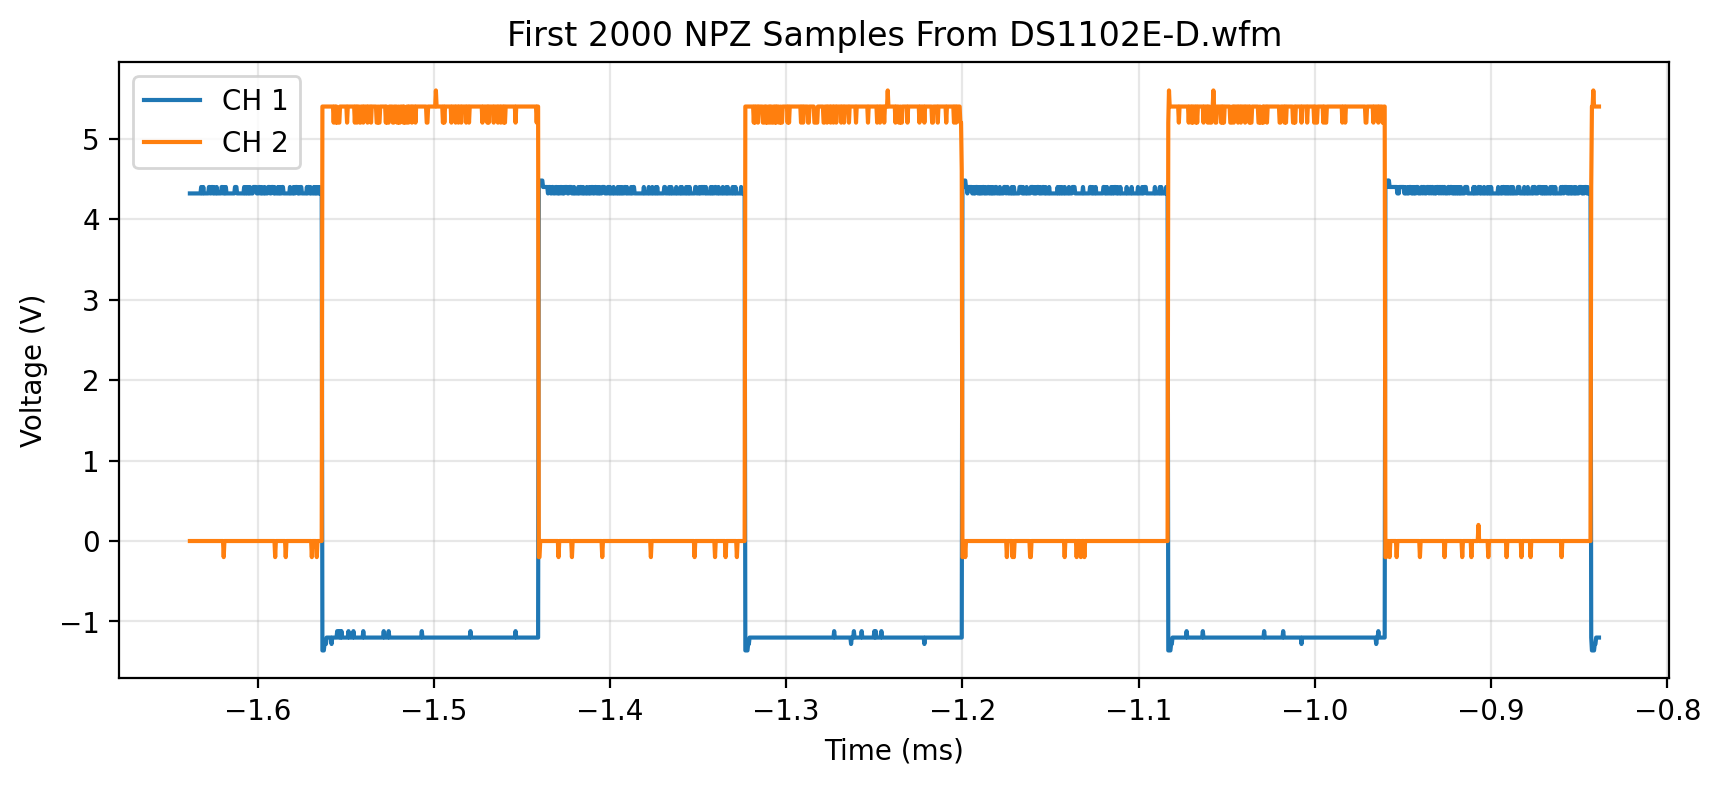

In [4]:
with tempfile.TemporaryDirectory() as tmpdir:
    npz_path = Path(tmpdir) / 'DS1102E-D.npz'
    analog.npz(npz_path)
    with np.load(npz_path) as archive:
        t = archive['time']
        ch1 = archive['CH_1']
        ch2 = archive['CH_2']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t[:2000] * 1e3, ch1[:2000], label='CH 1')
ax.plot(t[:2000] * 1e3, ch2[:2000], label='CH 2')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (V)')
ax.set_title('First 2000 NPZ Samples From DS1102E-D.wfm')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Command-Line Equivalent

The same export is available from `wfmconvert`:

```bash
wfmconvert npz DS1102E-D.wfm
```

Channel names are lightly sanitized for archive keys, so `CH 1` becomes `CH_1`.